# Demo: ThresholdPlot

This notebook is the primary reference for `ThresholdPlot` and includes compact examples for all main features.

In [1]:
import matplotlib.pyplot as plt

from pythermalcomfort.models import heat_index_rothfusz, pmv_ppd_iso, utci
from pythermalcomfort.plots.matplotlib import ThresholdPlot

## 1. Basic PMV Threshold Plot

Define x/y axes and their resolution, fixed model inputs, output thresholds, then render.

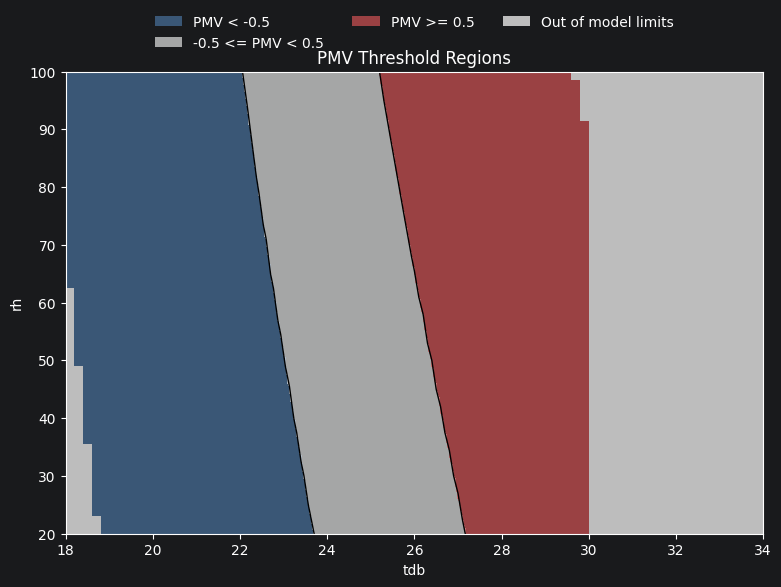

In [2]:
pmv_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="PMV Threshold Regions")
)

## 2. Custom Region Labels and Colors

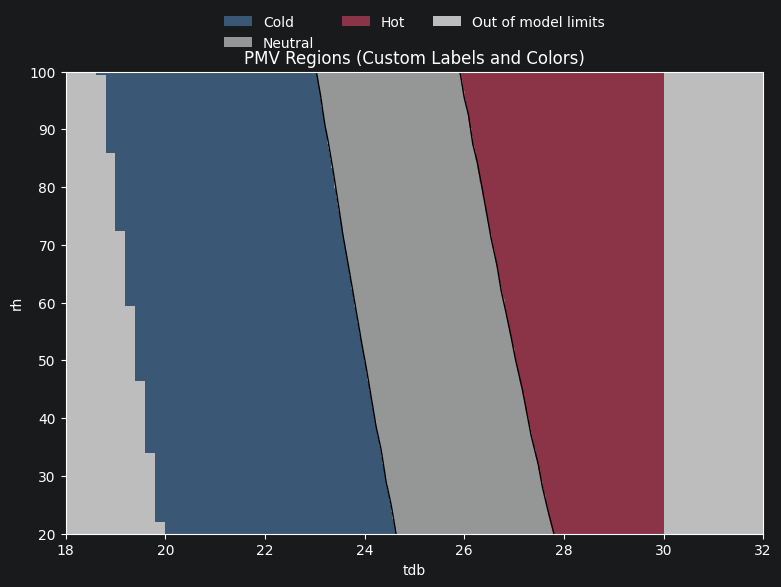

In [3]:
pmv_custom = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 32.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.20, met=1.2, clo=0.5, wme=0.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cold", "Neutral", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="PMV Regions (Custom Labels and Colors)")
)

## 3. Line, Fill, and Legend Styling

Use `line_kws`, `fill_kws`, and `legend_kws` for quick visual customization.

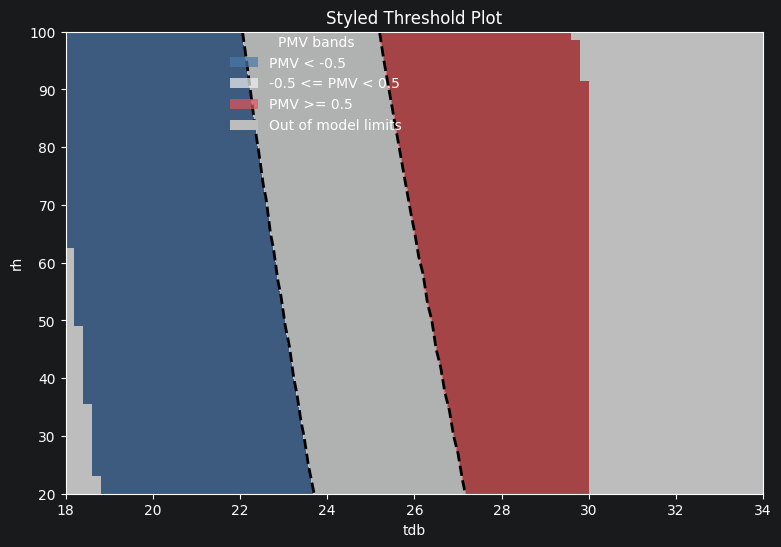

In [4]:
styled_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        title="Styled Threshold Plot",
        line_kws={"color": "black", "linewidth": 2.0, "linestyle": "dashed"},
        fill_kws={"alpha": 0.70},
        legend_kws={"title": "PMV bands", "ncol": 1, "loc": "upper right"},
    )
)

## 4. Invalid Region Rendering (`invalid_color`)

Customize how out-of-model cells are displayed in both plot and legend.

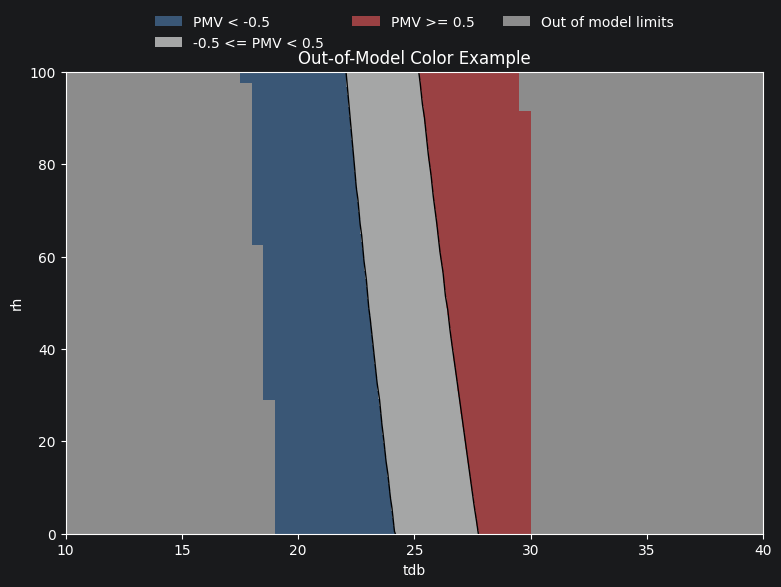

In [5]:
invalid_color_result = (
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=0.5)
    .set_y_axis("rh", 0.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(title="Out-of-Model Color Example", invalid_color="#8c8c8c")
)

## 5. Legend and Boundary-Line Toggles

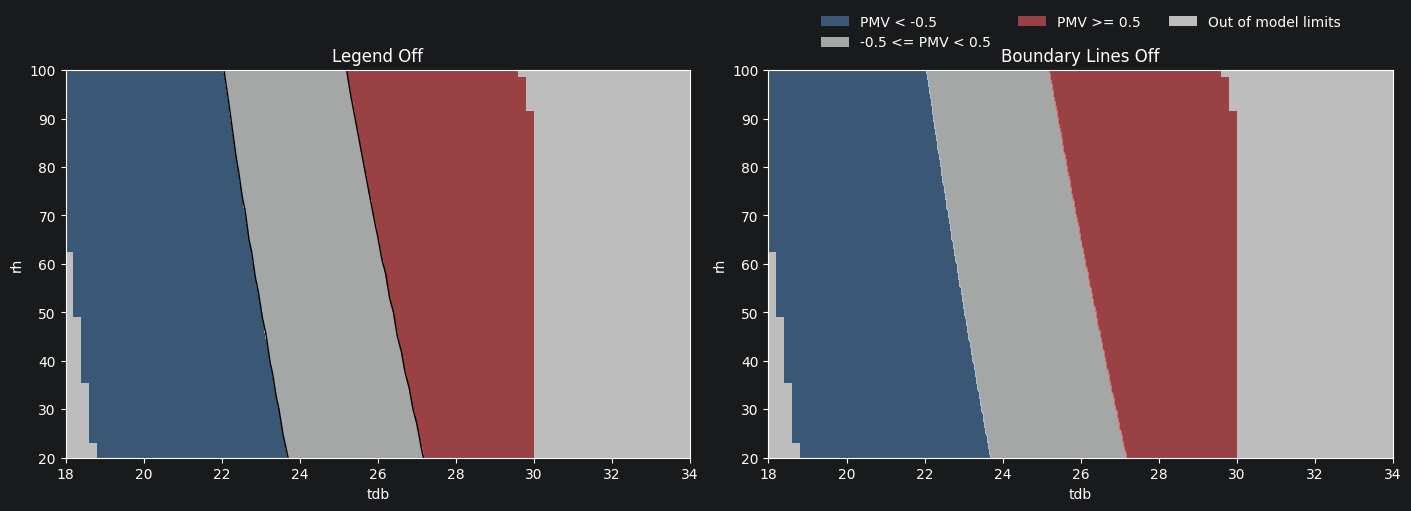

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="Legend Off", legend=False)
)

(
    ThresholdPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 18.0, 34.0, resolution=0.2)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(vr=0.10, met=1.2, clo=0.5, wme=0.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="Boundary Lines Off", show_lines=False)
)

plt.show()

## 6. Artist-Level Customization After Plot

Returned artists can be modified directly.

In [7]:
for line in pmv_result.lines:
    line.set_linewidth(2.5)

pmv_result.ax.set_xlabel("Air temperature [°C]")
pmv_result.ax.set_ylabel("Relative humidity [%]")
pmv_result.ax.grid(alpha=0.15)
plt.show()

## 7. UTCI Example

Text(0, 0.5, 'Relative humidity [%]')

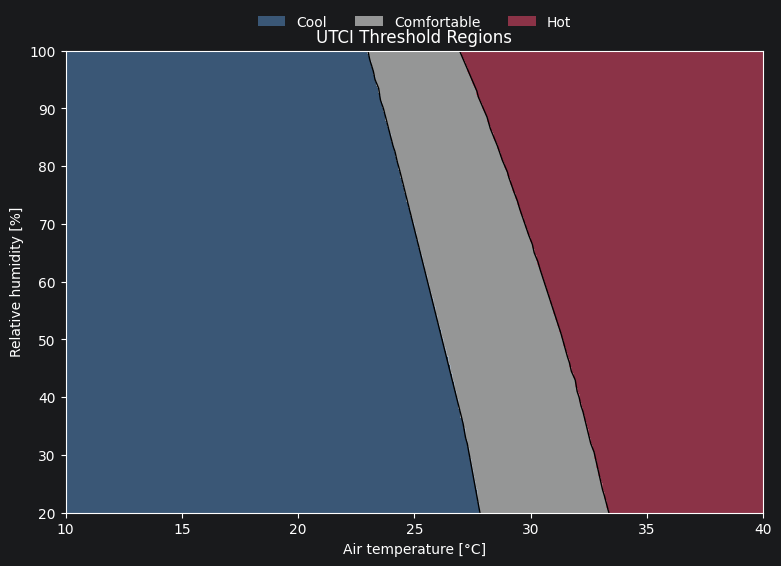

In [8]:
utci_result = (
    ThresholdPlot(utci)
    .set_x_axis("tdb", 10.0, 40.0, resolution=1.0)
    .set_y_axis("rh", 20.0, 100.0, resolution=0.5)
    .set_params(v=1.0)
    .set_regions(
        output="utci",
        thresholds=[26, 32],
        labels=["Cool", "Comfortable", "Hot"],
        colors=["#4c78a8", "#d9d9d9", "#c9415f"],
    )
    .plot(title="UTCI Threshold Regions")
)

utci_result.ax.set_xlabel("Air temperature [°C]")
utci_result.ax.set_ylabel("Relative humidity [%]")

## 8. Heat Index Example

Text(0, 0.5, 'Relative humidity [%]')

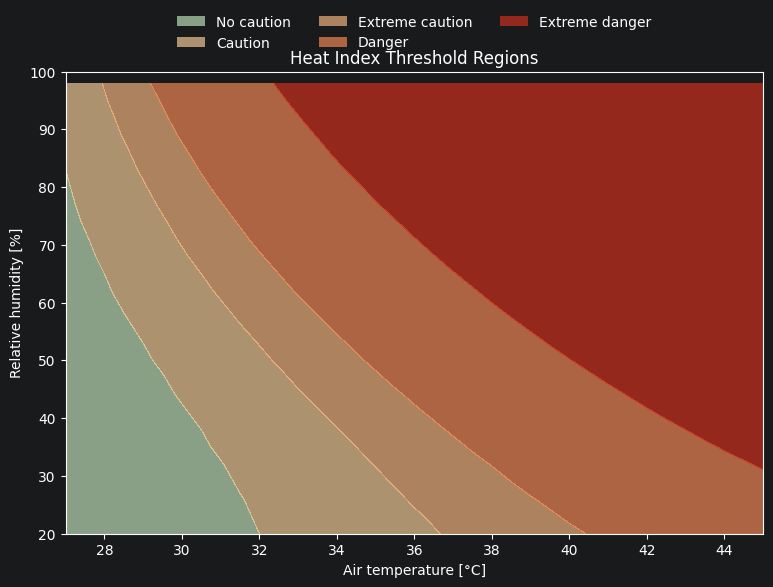

In [9]:
hi_result = (
    ThresholdPlot(heat_index_rothfusz)
    .set_x_axis("tdb", 27.0, 45.0, resolution=0.5)
    .set_y_axis("rh", 20.0, 100.0, resolution=3.0)
    .set_regions(
        output="hi",
        thresholds=[30.0, 35.0, 40.0, 55.0],
        labels=["No caution", "Caution", "Extreme caution", "Danger", "Extreme danger"],
        colors=["#c7e9c0", "#fdd49e", "#fdbb84", "#fc8d59", "#d7301f"],
    )
    .plot(title="Heat Index Threshold Regions", show_lines=False)
)

hi_result.ax.set_xlabel("Air temperature [°C]")
hi_result.ax.set_ylabel("Relative humidity [%]")